In [2]:
import pyvista as pv
import gmsh 
import numpy as np
import pandas as pd
import sys
sys.path.insert(1, './resources/')
#sys.path.insert(1, '/Users/amjonz/Documents/GitHub/mesher/src')
sys.path.insert(1, "./src")
import mesher_1 as mesh
sys.path.insert(1, '/Users/amjonz/Documents/GitHub/MOOSE_call/src')
import moosecall

import pyvista as pv
import time
from scipy.stats import norm
from scipy.stats import randint
import numpy as np
import pyro
import torch
import pyro.distributions as dist

In [2]:
pd.__version__

'2.2.3'

In [ ]:
#####   WORKING FUNCTIONS  #####
def XYZ_stress_tensor(z, rho, azimuth_deg, g=9.81, k_H=0.6, k_h=0.4, print_output=False):
    """
    Generalized stress tensor as a function of depth, considering faulting regimes
    and aligning the tensor with the azimuth of the maximum principal horizontal stress.
    #### IMPORTANT: THIS OUTPUTS A STRESS TENSOR THAT CONFORMS TO AN [ X Y Z ] COORDINATE SPACE #### 
    #### MANY TEXTBOOK EXAMPLES USE A NorthEastDown (NED) system e.g. Zoback 2010
    
    Parameters:
    z (float): Depth (negative meters below the surface).
    rho (float): Density of the overburden rock (kg/m^3).
    azimuth (float): Azimuth of maximum horizontal stress (degrees clockwise from north).
    g (float): Gravitational acceleration (m/s^2), default is 9.81 m/s^2.
    k_H (float): Proportionality constant for maximum horizontal stress (relative to vertical stress).
    k_h (float): Proportionality constant for minimum horizontal stress (relative to vertical stress).
    
    Returns:
    rotated_tensor (numpy.ndarray): 3x3 rotated stress tensor matrix based on the faulting regime in [X Y Z} coordinate space.
    """
    if z >= 0:
        raise ValueError("Depth (z) should be a negative value representing meters below the surface.")
    if print_output:
        print("Azi, SHMax: ", azimuth_deg)
    azimuth_deg = azimuth_deg+90
    # Calculate vertical stress due to gravity
    sigma_v = rho * (z)#rho * g * (-z)  # Vertical stress increases with depth
    
    # Calculate horizontal stresses
    sigma_H = k_H * sigma_v   # Maximum horizontal stress
    sigma_h = k_h * sigma_v   # Minimum horizontal stress
    if print_output:
        print("Sigma_H - K : ", sigma_H)
        print("Sigma_h - k : ", sigma_h)
        print("Sigma V: ", sigma_v)
    
    azimuth_rad = np.radians((azimuth_deg))
    # Determine the faulting regime
    if sigma_v < sigma_H < sigma_h:
        # Normal faulting regime: σ1 = σv, σ2 = σH, σ3 = σh
        sigma_xx, sigma_yy, sigma_zz = sigma_v, sigma_H, sigma_h
        alpha, beta, gamma = np.radians(azimuth_deg-90), np.radians(90), np.radians(0)
    elif sigma_H < sigma_v < sigma_h:
        # Strike-slip faulting regime: σ1 = σH, σ2 = σv, σ3 = σh
        sigma_xx, sigma_yy, sigma_zz = sigma_H, sigma_v, sigma_h
        alpha, beta, gamma = azimuth_rad, np.radians(0), np.radians(90)
    elif sigma_H < sigma_h < sigma_v:
        # Reverse faulting regime: σ1 = σH, σ2 = σh, σ3 = σv
        sigma_xx, sigma_yy, sigma_zz = sigma_H, sigma_h, sigma_v
        alpha, beta, gamma = azimuth_rad, np.radians(0), np.radians(0)
    else:
        raise ValueError("Invalid stress regime detected. Check input parameters.")
    
    # Assume no shear stresses (off-diagonal terms = 0)
    sigma_xy = sigma_xz = sigma_yz = 0.0
    
    # Build the initial stress tensor in the global coordinate system
    stress_tensor = np.array([
        [sigma_xx, sigma_xy, sigma_xz],
        [sigma_xy, sigma_yy, sigma_yz],
        [sigma_xz, sigma_yz, sigma_zz]
    ])
    if print_output:
        print("Principle Stress Tensor: \n",stress_tensor.round(3))
    # Convert azimuth to radians
    
    
    # Define the rotation matrix for the azimuth
    rotation_matrix = np.array([
        [np.cos(alpha)*np.cos(beta), np.sin(alpha)*np.cos(beta), -np.sin(beta)],
        [(np.cos(alpha)*np.sin(beta)*np.sin(gamma)) - (np.sin(alpha)*np.cos(gamma)),  (np.sin(alpha)*np.sin(beta)*np.sin(gamma)) + (np.cos(alpha)*np.cos(gamma)), (np.cos(beta)*np.sin(gamma))],
        [(np.cos(alpha)*np.sin(beta)*np.cos(gamma)) + (np.sin(alpha)*np.sin(gamma)),  (np.sin(alpha)*np.sin(beta)*np.cos(gamma)) - (np.cos(alpha)*np.sin(gamma)), (np.cos(beta)*np.cos(gamma))]
    ])
    if print_output:
        print("Rotation Matrix: \n", rotation_matrix.round(3))
    # Rotate the stress tensor to align with the azimuth
    rotated_tensor = rotation_matrix.T @ stress_tensor @ rotation_matrix
    if print_output:
        print("Rotated Matrix: \n",rotated_tensor.round(3))
    return rotated_tensor


In [4]:


def add_intersection_points(surfaces):
    """
    Add intersection points to each PyVista polydata surface based on intersections
    with other surfaces.

    Parameters:
        surfaces (list of pv.PolyData): List of PyVista PolyData surfaces.

    Returns:
        list of pv.PolyData: List of modified PolyData surfaces with added points.
    """
    if not all(isinstance(surface, pv.PolyData) for surface in surfaces):
        raise ValueError("All inputs must be PyVista PolyData surfaces.")

    modified_surfaces = []

    for i, surface_a in enumerate(surfaces):
        # Create a copy of the current surface to avoid modifying the input
        modified_surface = surface_a.copy()
        print(type(surface_a))
        #time.sleep(2)
        for j, surface_b in enumerate(surfaces):
            if i != j:  # Avoid self-intersection
                # Compute the intersection between surface_a and surface_b
                print(type(surface_b))
                intersection, s1, s2 = surface_a.intersection(surface_b)
                print(type(intersection))
                #time.sleep(2)
                # Check if the intersection has points
                print(intersection.n_points)
                #time.sleep(2)
                if intersection and intersection.n_points > 0:
                    # Add intersection points to the modified surface
                    points_to_add = pv.PolyData(intersection.points)
                    modified_surface = modified_surface.merge(points_to_add)

        modified_surfaces.append(modified_surface.clean(inplace=True).delaunay_2d())

    return modified_surfaces



def make_LOG_entry(meshLOG, meshLogCols, meshLogData):
        #logEntry = res = dict(map(lambda i,j : (i,j) , meshLogCols , meshLogData))
        #meshLOG = pd.DataFrame(columns=meshLogCols)
        #meshLOG.jo(pd.DataFrame(logEntry))
        colEntry = []
        #colEntry.append(meshLogCols)
        colEntry.append(meshLogData)
        meshLOG = pd.concat((meshLOG, pd.DataFrame(colEntry, columns=meshLogCols)))
        outputmeshLOG = pd.DataFrame(colEntry, columns=meshLogCols)
        print(outputmeshLOG)
        return meshLOG

def combine_columns_to_string(df: pd.DataFrame, index: int, columns: list) -> str:
            """
            Combine specified columns of a DataFrame row into a comma-separated string.
            Strips any apostrophes and brackets within the values, except for the ones closing the final string.
        
            :param df: pandas DataFrame
            :param index: Row index to retrieve values from
            :param columns: List of column names to include in the output string
            :return: Formatted string with combined values
            """
            values = [str(df.at[index, col]).replace("'", "").replace("[", "").replace("]", "").replace(",","") for col in columns]
            return f"'{', '.join(values).replace(",","")}'"



In [ ]:
#pv.PolyData.clip_surface??

In [ ]:
### Visual confirmation that the input surfaces extend past the boundaries and that everyone is in the right spot before meshing 

iter = 20
boundaries = (196000, 219000, 374000, 388000, -3000, 33)
#boundaries = (0, 400, 0, 300, -100, ,)
nsg = pv.read(f'./results/surfaces/cluster/nsg_input.vtk').delaunay_2d().decimate(0.99)
teg = pv.read(f'./results/surfaces/cluster/Tegelen_cal_mod9_1_E_{iter:04d}.vtk').clean()
dulk = pv.read(f'./results/surfaces/cluster/Dulkener_cal_mod9_1_E_{iter:04d}.vtk').clean()
belf = pv.read(f'./results/surfaces/cluster/Belfeld_cal_mod9_1_E_{iter:04d}.vtk').clean()
viers = pv.read(f'./results/surfaces/cluster/Viersen_cal_mod9_1_E_{iter:04d}.vtk').clean()
carbAnti = pv.read(f'./results/surfaces/cluster/carbFaultTegAnti_cal_mod9_1_E_{iter:04d}.vtk').clean()
ploty = pv.Plotter(notebook=True)
nsg = pv.read(f'./results/surfaces/cluster/nsg_input.vtk').delaunay_2d().decimate(0.99)

xmin, xmax, ymin, ymax, zmin, zmax = boundaries
clip_tegel = mesh.clip_polydata(teg.reconstruct_surface(), xmin, xmax, ymin, ymax, zmin, zmax)
clip_dulky = mesh.clip_polydata(dulk.reconstruct_surface(), xmin, xmax, ymin, ymax, zmin, zmax)
clip_belfy = mesh.clip_polydata(belf.reconstruct_surface(), xmin, xmax, ymin, ymax, zmin, zmax)
clip_viers = mesh.clip_polydata(viers.reconstruct_surface(), xmin, xmax, ymin, ymax, zmin, zmax)
clip_carbAnti = mesh.clip_polydata(carbAnti.reconstruct_surface(), xmin, xmax, ymin, ymax, zmin, zmax)

clipcarb = clip_carbAnti.clip_surface(nsg, invert=False)
#plane1 = pv.Plane(center=(0.2,.5,.5), direction=(1,0,0)).delaunay_2d().extract_surface()
#plane_vert = pv.Plane(center=(100,150,-50), direction=(1,0,0), i_size=120, j_size=320)
#vertical_plane = mesh.clip_polydata(plane_vert.triangulate(), xmin, xmax, ymin, ymax, zmin, zmax)


bbox = pv.Box(boundaries).extract_feature_edges()
ploty.add_mesh(bbox)
#ploty.add_mesh(vertical_plane.extract_all_edges(), opacity=0.7)
ploty.add_mesh(nsg, color='pink', opacity=0.2)
ploty.add_mesh(teg, opacity= ,.2, color="red")
ploty.add_mesh(clip_tegel, opacity= ,.4, color="red")
ploty.add_mesh(dulk, opacity=0.2, color="blue")
ploty.add_mesh(clip_dulky, opacity=0.4, color="blue")
ploty.add_mesh(belf, opacity=0.2, color ="green")
ploty.add_mesh(clip_belfy, opacity=0.4, color ="green")
ploty.add_mesh(clip_viers, opacity=0.4, color='blue')
ploty.add_mesh(clipcarb, opacity=0.5, color='grey')



ploty.show()


In [5]:
#####     FILE SYSTEM PATHS     ########


model_iter = 'Cal_mod9_1_E'

rootPath = "/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_model9_1_E/"
surfacesDir = "results/surfaces/cluster"
meshDir = "meshes/"
mooseInputDir = "nodalMooseInputFiles/"

In [ ]:

boundaries = (196000, 219000, 374000, 388000, -3000, 33)
xmin, xmax, ymin, ymax, zmin, zmax = boundaries

rootPath = "/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_model9_1_E/"
surfacesDir = "results/surfaces/"
nsg = pv.read(f'{rootPath}{surfacesDir}nsg_input.vtk').delaunay_2d().decimate(0.99)
carb = pv.read(f'{rootPath}{surfacesDir}namu_input.vtk').delaunay_2d().decimate(0.99)
zee = pv.read(f'{rootPath}{surfacesDir}zee_input.vtk').delaunay_2d().decimate(0.99)
plotty = pv.Plotter(notebook=True)
plotty.add_mesh(pv.Box(boundaries), opacity=0.3)
plotty.add_mesh(nsg)
plotty.add_mesh(carb)
plotty.add_mesh(zee)
plotty.show()

In [ ]:
# Loading the surfaces names and preliminary parameters from the Structual modeling output.


model_iter = 'cal_mod9_1_E'
data_path = '/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_model_9_obs/'
rootPath = "/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/"
surfacesDir = "results/surfaces/"
meshDir = "meshes/"
mooseInputDir = "nodalMooseInputFiles/"
fieldsize = 500

mooseInputPath = rootPath+mooseInputDir
#Surf_nsg_pointer =  f'{data_path}strat_surfaces/cal_mod8_Bottom_NSG_depth.shp'

meshLogCols = ['MeshVersion', 'mesh path', 'Moose inputfile path', 'MOOSE input filename(s)', 
                'Devonian Volumes', 'Carboniferous Volumes', 'NorthSeaGroup Volumes',
                'Zeeland_Base Surface_Elements', 'NSG_Base Surface_Elements', 
                'Belfeld Fault_Elements', 'Tegelen Fault_Elements',  'Dulkener Fault_Elements', 'Viersen Fault_Elements',
                'West Boundary_Elements', 'East Boundary_Elements', 'South Boundary_Elements', 'North Boundary_Elements', 'Base Boundary_Elements', 'Top Boundary_Elements',
                'Sv ratio K_SHMax', 'Sv ratio k_Shmin', 'Azimuth SHMax' ]


#Model boundaries  [195000,220000,373000,389000,-3500, 500]
boundaries = (196100, 218900, 374100, 387900, -3000, 33)
xmin, xmax, ymin, ymax, zmin, zmax = boundaries
extents= (xmin, (xmax-xmin), ymin, (ymax-ymin), zmin, (zmax-zmin))




In [30]:
#### REINITIALIZE MESHLOG ####

meshLOG = pd.DataFrame(None, columns=meshLogCols)

In [ ]:
#### THIS CELL TAKES A LONG TIME TO RUN 139 min for 200 MESHES

model_suffix_list = np.arange(50,300)


for model_suffix in model_suffix_list:
  
    #zeeland = pv.read(f'{rootPath}{surfacesDir}Zeemu_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    zeeland = pv.read(f'{rootPath}{surfacesDir}Zeemu_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    namurian = pv.read(f'{rootPath}{surfacesDir}Namurian_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    #nsg = pv.read(f'{rootPath}{surfacesDir}NSG_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    nsg = pv.read(f'{rootPath}{surfacesDir}nsg_input.vtk').delaunay_2d().decimate(0.996)
    tegel = pv.read(f'{rootPath}{surfacesDir}Tegelen_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    dulk =  pv.read(f'{rootPath}{surfacesDir}Dulkener_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    belf =  pv.read(f'{rootPath}{surfacesDir}Belfeld_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    vier =  pv.read(f'{rootPath}{surfacesDir}Viersen_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()
    carbA = pv.read(f'{rootPath}{surfacesDir}carbFaultTegAnti_{model_iter}_{model_suffix:04d}.vtk').delaunay_2d()

    print(f"Currently building mesh from surfaces: {model_iter}_{model_suffix:04d}")
    xmin, xmax, ymin, ymax, zmin, zmax = boundaries

    clip_zeeland = mesh.clip_polydata(zeeland, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_namurian = mesh.clip_polydata(namurian, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_NSG = mesh.clip_polydata(nsg, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_tegel = mesh.clip_polydata(tegel, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_dulky = mesh.clip_polydata(dulk, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_belfy = mesh.clip_polydata(belf, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_viers = mesh.clip_polydata(vier, xmin, xmax, ymin, ymax, zmin, zmax).clean()
    clip_carba = mesh.clip_polydata(carbA, xmin, xmax, ymin, ymax, zmin, zmax).clean()

    clip_namurian_at_dulky = clip_namurian.clip_surface(clip_dulky)
    clip_carba_at_NSG = clip_carba.clip_surface(clip_NSG, invert=False)

    #surface_names = ["Belfeld", "Tegelen", "Dulkener", "Viersen", "Zeeland", "Namurian", "NSG"]
    #surfaces = [clip_belfy, clip_tegel, clip_dulky, clip_viers, clip_carba_at_NSG, clip_zeeland, clip_namurian_at_dulky, clip_NSG]
    

    meshPath = f"{rootPath}{meshDir}{model_iter}_{model_suffix:04d}_FS_{fieldsize}.msh"
    model_name = f"{model_iter}_{model_suffix}_FS_{fieldsize}"
    #vol_names= ['Belfeld_blk', 'Tegelen_blk', 'Dulkener_blk', 'Viersen_blk', 'ZeelandFm', 'NamurianFM', 'NSG']

    #build_mesh_from_surfaces(all_surfaces=[], surface_names=[], volume_names=[], model_name="divided_volume", output_file='./mesher.msh', bounding_box=[0,1,0,1,0,1], fieldsize=500)
    dim2_elements_catalog = []
    dim3_elements_catalog = []
    #dim2_elements_lists, dim3_elements_lists = mesh.build_mesh_from_surfaces(all_surfaces=surfaces, surface_names=surface_names, volume_names=vol_names, 
    #                         model_name=model_name, output_file=f'./meshes/{model_iter}{model_suffix:04d}_fieldsize_{fieldsize}.msh', bounding_box=boundaries, fieldsize=500)
    
    all_horizons= [clip_zeeland, clip_NSG]
    volume_names = ['Devonian', 'Carboniferous', 'NSG']
    vol_surface_names = ['Zeeland_base', 'NSG_base']
    all_faults = [clip_belfy, clip_tegel, clip_dulky, clip_viers]#, clip_carba_at_NSG]
    fault_surface_names =["Belfeld", "Tegelen", "Dulkener", "Viersen"]# , "CarboniferousTegelenAnti"]


    dim2_elements_lists, dim3_elements_lists = mesh.build_mesh_from_surfaces(all_horizons=all_horizons, volume_names=volume_names, vol_surface_names=vol_surface_names, all_faults=all_faults, 
                                                                            fault_surface_names=fault_surface_names, model_name=f"{model_iter}_{model_suffix:04d}", output_file=f'{rootPath}{meshDir}{model_iter}_{model_suffix:04d}_FS_{fieldsize}.msh', 
                                                                            bounding_box=boundaries, fieldsize=fieldsize)

    dim2_elements_catalog.append(dim2_elements_lists)
    dim3_elements_catalog.append(dim3_elements_lists)
    
    #meshFilePath = f"{rootPath}{meshDir}{model_iter}_{model_suffix:04d}_FS_{fieldsize}.msh"
    #mooseInputDirPath = f"{rootPath}{mooseInputDir}"

    meshLogData = [f'{model_suffix:04d}', meshPath, mooseInputPath, [],
                    dim3_elements_lists[0], dim3_elements_lists[1], dim3_elements_lists[2], dim2_elements_lists[0], dim2_elements_lists[1], dim2_elements_lists[2],
                    dim2_elements_lists[3],  dim2_elements_lists[4],  dim2_elements_lists[5],  dim2_elements_lists[6], dim2_elements_lists[7], 
                    dim2_elements_lists[8], dim2_elements_lists[9], dim2_elements_lists[10], dim2_elements_lists[11], 1.3, ,.8, 128]
    

    
    meshLOG = make_LOG_entry(meshLOG, meshLogCols, meshLogData)
    #meshLogData
    #meshLOG.to_csv("meshLOG_2_5k_fixed.csv")



   

Currently building mesh from surfaces: cal_mod9_1_E_0263
Orig:  (2, 1)  Children:  [(2, 848), (2, 852)]                                                              
Children:  [(2, 848), (2, 852)]
Adding (2, 848) : West
Adding (2, 852) : West
Orig:  (2, 2)  Children:  [(2, 851), (2, 855)]
Children:  [(2, 851), (2, 855)]
Adding (2, 851) : East
Adding (2, 855) : East
Orig:  (2, 3)  Children:  [(2, 849), (2, 853)]
Children:  [(2, 849), (2, 853)]
Adding (2, 849) : South
Adding (2, 853) : South
Orig:  (2, 4)  Children:  [(2, 850), (2, 854)]
Children:  [(2, 850), (2, 854)]
Adding (2, 850) : North
Adding (2, 854) : North
Orig:  (2, 5)  Children:  [(2, 5)]
Children:  [(2, 5)]
Adding (2, 5) : Base
Orig:  (2, 6)  Children:  [(2, 6)]
Children:  [(2, 6)]
Adding (2, 6) : Top
Orig:  (2, 7)  Children:  [(2, 7)]
Children:  [(2, 7)]
Adding (2, 7) : Zeeland_base
Orig:  (2, 8)  Children:  [(2, 8)]
Children:  [(2, 8)]
Adding (2, 8) : Zeeland_base
Orig:  (2, 9)  Children:  [(2, 9)]
Children:  [(2, 9)]
Add

Info    : 957 edge swaps, 233 node relocations (volume = 6.83619e+10): worst = 3.93907e-09 / average = 0.653113 (Wall 0.0221842s, CPU 0.022371s)
Info    : 1151 edge swaps, 409 node relocations (volume = 6.83619e+10): worst = 5.37601e-06 / average = 0.656123 (Wall 0.0636999s, CPU 0.056221s)
Info    : 1216 edge swaps, 511 node relocations (volume = 6.83619e+10): worst = 5.37601e-06 / average = 0.656946 (Wall 0.0849262s, CPU 0.076172s)
Info    : 0.00 < quality < 0.10 :       654 elements
Info    : 0.10 < quality < 0.20 :       381 elements
Info    : 0.20 < quality < 0.30 :       471 elements
Info    : 0.30 < quality < 0.40 :       954 elements
Info    : 0.40 < quality < 0.50 :      1236 elements
Info    : 0.50 < quality < 0.60 :      1589 elements
Info    : 0.60 < quality < 0.70 :      2176 elements
Info    : 0.70 < quality < 0.80 :      3746 elements
Info    : 0.80 < quality < 0.90 :      3685 elements
Info    : 0.90 < quality < 1.00 :      1690 elements
Info    : Optimizing volume 17
In

Info    : 1099 edge swaps, 215 node relocations (volume = 4.74404e+10): worst = 4.88243e-05 / average = 0.604444 (Wall 0.0267373s, CPU 0.026909s)
Info    : 0.00 < quality < 0.10 :       550 elements
Info    : 0.10 < quality < 0.20 :       393 elements
Info    : 0.20 < quality < 0.30 :       391 elements
Info    : 0.30 < quality < 0.40 :       763 elements
Info    : 0.40 < quality < 0.50 :      1097 elements
Info    : 0.50 < quality < 0.60 :      1561 elements
Info    : 0.60 < quality < 0.70 :      2054 elements
Info    : 0.70 < quality < 0.80 :      2096 elements
Info    : 0.80 < quality < 0.90 :      1913 elements
Info    : 0.90 < quality < 1.00 :       867 elements
Info    : Optimizing volume 23
Info    : Optimization starts (volume = 6.07181e+10) with worst = 8.19431e-06 / average = 0.630978:
Info    : 0.00 < quality < 0.10 :       777 elements
Info    : 0.10 < quality < 0.20 :       499 elements
Info    : 0.20 < quality < 0.30 :       618 elements
Info    : 0.30 < quality < 0.40 : 

Info    : Done writing '/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/meshes/fixed/cal_mod9_1_E_0263_FS_400.msh'
  MeshVersion                                          mesh path  \
0        0263  /Users/amjonz/SIEGFRIED/Californie_fault_stabi...   

                                Moose inputfile path MOOSE input filename(s)  \
0  /Users/amjonz/SIEGFRIED/Californie_fault_stabi...                      []   

                                    Devonian Volumes  \
0  [Devonian_0001, Devonian_0006, Devonian_0017, ...   

                               Carboniferous Volumes  \
0  [Carboniferous_0003, Carboniferous_0008, Carbo...   

                               NorthSeaGroup Volumes  \
0  [NSG_0005, NSG_0010, NSG_0016, NSG_0023, NSG_0...   

                       Zeeland_Base Surface_Elements  \
0  [Zeeland_base_1185, Zeeland_base_1184, Zeeland...   

                           NSG_Base Surface_Elements  \
0  [NSG_base_1772, NSG_base_1771, NSG_base_1770, ...  

In [12]:
meshLOG

NameError: name 'meshLOG' is not defined

In [7]:
""" RUN THIS CELL TO LOAD AN ALREADY CONSTRUCTED MESHLOG FROM FILE (*.csv)"""
model_iter = 'cal_mod9_1_E'
data_path = '/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_model_9_obs/'
rootPath = "/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/"
surfacesDir = "results/surfaces/"
meshDir = "meshes/"
mooseInputDir = "nodalMooseInputFiles/"
fieldsize = 500

mooseInputPath = rootPath+mooseInputDir
#Surf_nsg_pointer =  f'{data_path}strat_surfaces/cal_mod8_Bottom_NSG_depth.shp'

meshLogCols = ['MeshVersion', 'mesh path', 'Moose inputfile path', 'MOOSE input filename(s)', 
                'Devonian Volumes', 'Carboniferous Volumes', 'NorthSeaGroup Volumes',
                'Zeeland_Base Surface_Elements', 'NSG_Base Surface_Elements', 
                'Belfeld Fault_Elements', 'Tegelen Fault_Elements',  'Dulkener Fault_Elements', 'Viersen Fault_Elements',
                'West Boundary_Elements', 'East Boundary_Elements', 'South Boundary_Elements', 'North Boundary_Elements', 'Base Boundary_Elements', 'Top Boundary_Elements',
                'Sv ratio K_SHMax', 'Sv ratio k_Shmin', 'Azimuth SHMax' ]


#Model boundaries  [195000,220000,373000,389000,-3500, 500]
boundaries = (196100, 218900, 374100, 387900, -3000, 33)
xmin, xmax, ymin, ymax, zmin, zmax = boundaries
extents= (xmin, (xmax-xmin), ymin, (ymax-ymin), zmin, (zmax-zmin))


#meshLOG.at[0, 'MOOSE input filename(s)'] = []
#meshLOG.loc[0,'MOOSE input filename(s)'].append('0')
meshLOGread = pd.read_csv("meshLOG_250.csv")
meshLOGread = meshLOGread[meshLogCols]
#meshLOGread["MeshVersion"].astype(str)
meshLOGread["MeshVersion"] = meshLOGread["MeshVersion"].map(lambda x: f'{x:04d}')
meshLOGread["MOOSE input filename(s)"] = meshLOGread["MOOSE input filename(s)"].map(lambda x: list())
meshLOGread["mesh path"] = meshLOGread["MeshVersion"].map(lambda x: f'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/meshes/{model_iter}_{x}_FS_{fieldsize}.msh')
type(meshLOGread.loc[0,"MOOSE input filename(s)"])
meshLOGread.loc[6, 'Moose inputfile path']

'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/mooseInputFiles/'

In [14]:
from scipy.stats import norm
from scipy.stats import randint
import numpy as np
import pyro
import torch
import pyro.distributions as dist



def randomStateGenerator(df, meshLOG, k_H, k_H_var, k_h, k_h_var, azimuth, azimuth_var, n_picks, **kwargs):

    '''This creates or adds to an existing pandas Dataframe a probabilistic series of Maximum and minimum horizontal 
    stress ratios blended with a randomly selected geometry from the meshLOG input
    
    Parameters
    df : (pandas DataFrame) Empty or an exisiting set of realizations to add to
    meshLOG : (pandas DataFrame) mesh dataset that informs the "df_prob" output
    k_H :(float) ratio of maximum to vertical horizontal stress
    k_H_var : (float) variance of normal distribution of uncertainties for k_H
    k_h : (float) ratio of minimum to vertical horizontal stress
    k_h_var : (float) variance of normal distribution of uncertainties for k_h
    azimuth : (float) azimuth direction of k_H (Maximum horizontal stress)
    azimuth_var : (float) variance of normal distribution of uncerainty for azimuth
    n_picks : (int) number of probabilistic combinations to produce
       
    Returns
    df : (pandas DataFrame) combination of probabilistic picks

    '''
    #meshLogCols = ['MeshVersion', 'mesh path', 'Moose input path', 'Volume Count', 'Ext Surf Count','Dulkener Count', 'Tegelen Count', 'Belfeld Count','Magnitude SHMax', 'Magnitude SHmin', 'Direction SHMax' ]
    
    #meshLOG = pd.DataFrame(None, columns=meshLogCols)

    # building the ability to select from a narrow portion of the meshes
    meshLOG = meshLOG.copy(deep=True)
    start = kwargs.get("start")
    end = kwargs.get("end")
    correlation = kwargs.get("correlation")
    
    if start == None:
        start=1
    if end == None:
        end = len(meshLOG.index)
    if correlation == None:
        correlation = 1e-6

    n_meshes = randint.rvs(low=start, high=end, size=n_picks)
    azimuth_picks = norm.rvs(loc=azimuth, scale=azimuth_var, size=n_picks)

    def generate_MultivariateNormal_randomVar(k_H, k_H_var, k_h, k_h_var):
        variance = np.array([[k_H_var],[k_h_var]])
        cov_matrix = (correlation * variance.min()) * np.ones((2, 2)) - (correlation * variance.min())*np.eye(2) + (variance)*(np.eye(2))  #Adding point-zero-one for numerical stability
        #print("Covariance Matrix", cov_matrix)
        mean_tensor = torch.tensor(np.array([k_H, k_h]), dtype=torch.float32)
        cov_tensor = torch.tensor(cov_matrix, dtype=torch.float32)
    
        return pyro.sample(f"KH_kh", dist.MultivariateNormal(mean_tensor, cov_tensor))

    k_H_picks = []
    k_h_picks = []
    for i in range(n_picks):
        corrK = generate_MultivariateNormal_randomVar(k_H, k_H_var, k_h, k_h_var) # Correlated random pick for K_H / k_h
        

        #Accept/reject parameters for ramdom selection (Cannot be Reverse faulting or have a negative k ratio)
        stress_state_is_rejected = True
        
        while stress_state_is_rejected:
            if 1.0 > corrK[1] > 0.4 and corrK[0] > corrK[1]:       
                stress_state_is_rejected = False
            else:
                #stress_state_is_rejected = True
                corrK = generate_MultivariateNormal_randomVar(k_H, k_H_var, k_h, k_h_var)
        #print('K_H ', corrK[0], ' k_h ', corrK[1])
        #Simple random varable pick from normal distribution 
        #k_H_picks = norm.rvs(loc=k_H, scale=k_H_var, size=n_picks)
        #k_h_picks = norm.rvs(loc=k_h, scale=k_h_var, size=n_picks)

        k_H_picks.append(corrK[0].numpy()) # Correlation K value SHMax
        k_h_picks.append(corrK[1].numpy()) # Correlation K value Shmin


    #listt = list()

    all_picks = zip(k_H_picks, k_h_picks, azimuth_picks, n_meshes)

        # 'Sv ratio K_SHMax', 'Sv ratio k_Shmin', 'Azimuth SHMax' 
    for idx, pick in enumerate(all_picks, start=0):

        meshHOP = meshLOG[meshLOG['MeshVersion'] == f"{pick[3]:04d}"].copy()
        #print(meshHOP.loc[0,'Sv ratio K_SHMax'])
        meshHOP['Sv ratio K_SHMax'] = pick[0]
        meshHOP['Sv ratio k_Shmin'] = pick[1]
        meshHOP['Azimuth SHMax'] = pick[2]
        #meshHOP.loc[0,'Moose inputfile path'] = listt
        if idx == 0:
            df = meshHOP
        else:
            df = pd.concat((df, meshHOP))

    return df.reset_index(drop=True)

mooseLOG = pd.DataFrame(columns=meshLogCols)
k_H=1.3 
k_H_var=.2
k_h=0.7
k_h_var=.15
azimuth=128
azimuth_var=10
n_picks=2500
  




In [ ]:
meshLOGread.iloc[212]
#meshLOGread.to_csv("meshLOG_nodal_2_5k.csv")

In [24]:
df_picks.iloc[3]

Unnamed: 0.1                                                                     3
Unnamed: 0                                                                       3
MeshVersion                                                                   0263
mesh path                                   ../meshes/cal_mod9_1_E_0263_FS_400.msh
Moose inputfile path             /Users/amjonz/SIEGFRIED/Californie_fault_stabi...
MOOSE input filename(s)                                                         []
Devonian Volumes                 ['Devonian_0001', 'Devonian_0006', 'Devonian_0...
Carboniferous Volumes            ['Carboniferous_0003', 'Carboniferous_0008', '...
NorthSeaGroup Volumes            ['NSG_0005', 'NSG_0010', 'NSG_0016', 'NSG_0023...
Zeeland_Base Surface_Elements    ['Zeeland_base_1185', 'Zeeland_base_1184', 'Ze...
NSG_Base Surface_Elements        ['NSG_base_1772', 'NSG_base_1771', 'NSG_base_1...
Belfeld Fault_Elements           ['Belfeld_0833', 'Belfeld_0832', 'Belfeld_0831...
Tege

In [ ]:
#df_picks = randomStateGenerator(mooseLOG, meshLOGread, k_H, k_H_var, k_h, k_h_var, azimuth, azimuth_var, n_picks, start=51, end=300, correlation=0.8)

In [32]:
#df_picks = randomStateGenerator(mooseLOG, meshLOGread, k_H, k_H_var, k_h, k_h_var, azimuth, azimuth_var, n_picks, start=51, end=300, correlation=0.8)
cols = ['Devonian Volumes', 'Carboniferous Volumes',
       'NorthSeaGroup Volumes', 'Zeeland_Base Surface_Elements','NSG_Base Surface_Elements', 'Belfeld Fault_Elements',
       'Tegelen Fault_Elements', 'Dulkener Fault_Elements',
       'Viersen Fault_Elements']
#for col in cols:
#    df_picks[col].iloc[3] = meshLOG[col].iloc[0]
    #print(col)

#df_picks[['Devonian Volumes', 'Carboniferous Volumes',
#       'NorthSeaGroup Volumes', 'Zeeland_Base Surface_Elements',
#       'NSG_Base Surface_Elements', 'Belfeld Fault_Elements',
#       'Tegelen Fault_Elements', 'Dulkener Fault_Elements',
#       'Viersen Fault_Elements']].iloc[3] 
#df.loc[df['column_name'] == some_value]
locs = df_picks.loc[df_picks['MeshVersion'] == '0263'].index

locs
df_picks.iloc[138]
#for col in cols:
#    meshLOGread[col].iloc[212] = df_picks[col].iloc[3]#  = meshLOG[col].iloc[0]
#for col in cols:
#    df_picks[col].iloc[3] = meshLOG[col].iloc[0]
    #print(col)


MeshVersion                                                                   0263
mesh path                        /Users/amjonz/SIEGFRIED/Californie_fault_stabi...
Moose inputfile path             /Users/amjonz/SIEGFRIED/Californie_fault_stabi...
MOOSE input filename(s)                                                         []
Devonian Volumes                 ['Devonian_0001', 'Devonian_0006', 'Devonian_0...
Carboniferous Volumes            ['Carboniferous_0003', 'Carboniferous_0008', '...
NorthSeaGroup Volumes            ['NSG_0005', 'NSG_0010', 'NSG_0016', 'NSG_0023...
Zeeland_Base Surface_Elements    ['Zeeland_base_1185', 'Zeeland_base_1184', 'Ze...
NSG_Base Surface_Elements        ['NSG_base_1772', 'NSG_base_1771', 'NSG_base_1...
Belfeld Fault_Elements           ['Belfeld_0833', 'Belfeld_0832', 'Belfeld_0831...
Tegelen Fault_Elements           ['Tegelen_0931', 'Tegelen_0930', 'Tegelen_0929...
Dulkener Fault_Elements          ['Dulkener_0995', 'Dulkener_0994', 'Dulkener_0...
Vier

In [ ]:
""" UNCOMMECT TO SAVE OUT THE COMPUTED RANDOMIZED STRESS AND MESH PICKS FROM THE RANDOM STATE GENERATOR"""

#df_picks.to_csv("df_picks_nodal_final_2_5k.csv")
#df_picks['mesh path'].iloc[1]

NameError: name 'df_picks' is not defined

In [71]:
#df_picks['Moose inputfile path']='/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/nodalMooseInputFiles/'

df_picks['Devonian Volumes'].iloc[3]

['Devonian_0001',
 'Devonian_0006',
 'Devonian_0017',
 'Devonian_0018',
 'Devonian_0019',
 'Devonian_0020']

In [ ]:
# UnCOMMENT TO restore first 2k picks ++++++ + + LOCAL SIMULATIONS + + +++++++
'''
df_picks = pd.read_csv("df_picks_nodal_2k.csv")
df_picks["MeshVersion"] = df_picks["MeshVersion"].map(lambda x: f'{x:04d}')
df_picks["MOOSE input filename(s)"] = meshLOGread["MOOSE input filename(s)"].map(lambda x: list())
df_picks["mesh path"] = df_picks["MeshVersion"].map(lambda x: f'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/meshes/{model_iter}_{x}_FS_{fieldsize}.msh')
'''


In [12]:
# UnCOMMENT TO restore first 2k picks ++++++ + + HPC SIMULATIONS + + +++++++
df_picks = pd.read_csv("df_picks_nodal_final_2_5k.csv")
df_picks["MeshVersion"] = df_picks["MeshVersion"].map(lambda x: f'{x:04d}')
df_picks["MOOSE input filename(s)"] = meshLOGread["MOOSE input filename(s)"].map(lambda x: list())
df_picks["mesh path"] = df_picks["MeshVersion"].map(lambda x: f'../meshes/{model_iter}_{x}_FS_{fieldsize}.msh')


In [17]:
df_picks['Sv ratio K_SHMax'].max(), df_picks['Sv ratio k_Shmin'].max()

(np.float64(2.527444), np.float64(0.9993303))

In [34]:
for i in range(len(df_picks.index)):
    filename = f"CAL_model_9_1E_FS{fieldsize}_{i+1:04d}.i"
    file_path = df_picks.loc[i,'Moose inputfile path']#'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/RUN_2_Cal_model8_epochD/mooseInputFiles/'
    mesh_path = df_picks.loc[i,'mesh path']#'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/RUN_2_Cal_model8_epochD/meshes/Cal_mod8_4_d0001_fieldsize_400.msh'
    version = f"CAL_model_9_1E_FS{fieldsize}_{i+1:04d}"

    desc = f"Californie Fault Stability Study for Mesh {df_picks.loc[i,'MeshVersion']}, with K_H {df_picks.loc[i,'Sv ratio K_SHMax']}, K_h {df_picks.loc[i,'Sv ratio k_Shmin']},  SHMax Azimuth {df_picks.loc[i,"Azimuth SHMax"]}"
    simulation_name = 'Projected stress fault stability study. Density, considering effective stress Devonian: 1640, Carboniferous: 1590, NSG: 1380'

    density_dict = {"Devonian": ["1640", combine_columns_to_string(df=df_picks, index=i, columns=["Devonian Volumes"])], 
                                "Carboniferous": ["1590", combine_columns_to_string(df=df_picks, index=i, columns=["Carboniferous Volumes"])],
                                            # "Namurian": ["2400", combine_columns_to_string(df=meshLOG, index=0, columns=["Namurian Volumes"])], 
                                                            "NorthSeaGroup": ["1380", combine_columns_to_string(df=df_picks, index=i, columns=["NorthSeaGroup Volumes"])]}

    
    moosecallout = moosecall.mooseCall(filename=filename, file_path=file_path, mesh_path=mesh_path, version=version, parameters_df=df_picks.loc[[i]], surface_elev=33, density_dict=density_dict, description=desc, simulation_name=simulation_name, df_index=i)
    
    moosecallout.obj_parameters()
    moosecallout.multiapp_fault_stability()
    #moosecallout.preGravity_stress()
    #df_picks.at[i, 'MOOSE input filename(s)'].append(f"CAL_model_8_8D_FS400_{i:04d}_pre_grav.i")
    #moosecallout.fault_stability_projected_stress_sim_with_direction()
    #df_picks.at[i, 'MOOSE input filename(s)'].append(f"CAL_model_8_8D_FS400_{i:04d}_fault_stability.i")
  

Write path :  /Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/mooseInputFiles/CAL_model_9_1E_FS400_0001.i
Mesh path :  /Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/meshes/cal_mod9_1_E_0086_FS_400.msh
Version :  CAL_model_9_1E_FS400_0001
Surface Elevation :  33
Formation Densities dictionary: {'Devonian': ['1640', "'Devonian_0007 Devonian_0012 Devonian_0026 Devonian_0027 Devonian_0028 Devonian_0029'"], 'Carboniferous': ['1590', "'Carboniferous_0009 Carboniferous_0014 Carboniferous_0020 Carboniferous_0021 Carboniferous_0030 Carboniferous_0031 Carboniferous_0032'"], 'NorthSeaGroup': ['1380', "'NSG_0004 NSG_0005 NSG_0006 NSG_0011 NSG_0016 NSG_0022 NSG_0024 NSG_0025 NSG_0033 NSG_0034'"]}
All Mesh Blocks :  'Devonian_0007 Devonian_0012 Devonian_0026 Devonian_0027 Devonian_0028 Devonian_0029 Carboniferous_0009 Carboniferous_0014 Carboniferous_0020 Carboniferous_0021 Carboniferous_0030 Carboniferous_0031 Carboniferous_0032 NSG_0004 NSG_0005 

In [ ]:
df_picks["MOOSE input filename(s)"][1]

In [ ]:
type(df_picks.loc[0,"Devonian Volumes"])

(array([15.,  8.,  9.,  8., 12., 13.,  6.,  6., 21.,  8., 10.,  9.,  9.,
        12.,  8., 11., 11.,  9., 10.,  6., 20.,  8.,  9.,  6.,  9.,  4.,
        11.,  8.,  3., 11., 13., 10., 12., 12.,  8., 15.,  6., 10.,  8.,
        11., 11.,  8.,  7., 13., 12., 18.,  7.,  4., 21., 13., 10., 14.,
         8.,  9., 10., 15., 10., 11., 10.,  6.,  8., 12.,  9.,  6., 11.,
         7.,  9., 10.,  9.,  4., 10.,  6.,  9.,  6., 10.,  6., 14.,  8.,
         8., 12., 10.,  8., 13.,  8., 10.,  9., 14.,  5.,  7., 11.,  7.,
        13.,  7.,  8., 11., 10., 10.,  8.,  8., 10.,  7., 10., 11.,  7.,
        21., 10., 18.,  9., 10.,  8.,  8.,  5.,  9.,  5.,  9., 11.,  7.,
        14., 14., 13., 13., 10., 11.,  9., 10., 16., 11., 16.,  9., 10.,
         9., 17., 11., 13.,  5., 12.,  9.,  7.,  5., 13.,  7.,  8.,  9.,
        10., 14., 10., 11., 14.,  9., 11., 16.,  5.,  7.,  8., 18., 12.,
        14.,  8., 16., 14.,  7., 10., 19., 12., 11., 14.,  8.,  7.,  5.,
        11., 14., 11.,  9.,  8.,  6.,  9., 10., 11.

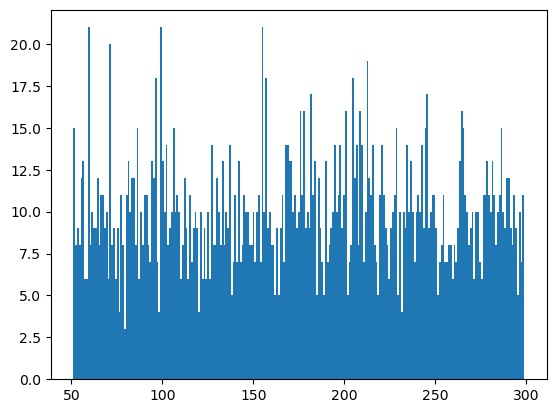

In [51]:
meshvers = np.zeros(2500)
for i in range(2500):
    meshvers[i]=(int(df_picks["MeshVersion"][i]))
import matplotlib.pyplot as plt
plt.hist(meshvers, bins=249)

In [ ]:
df_picks.hist??

Text(0.5, 1.0, 'Azimuth SHmax')

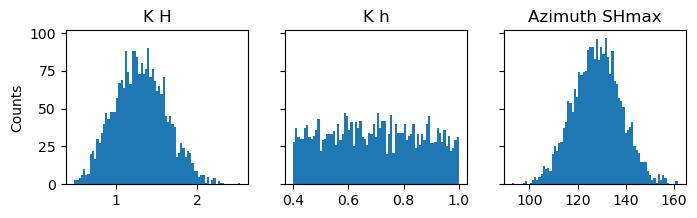

In [33]:
import matplotlib.pyplot as plt
stress_stats = pd.DataFrame(df_picks[['Sv ratio K_SHMax', 'Sv ratio k_Shmin', 'Azimuth SHMax']].values, columns=['K H', 'K h', 'Azimuth SHmax'])
#stress_stats.head()
#stress_stats.hist(bins=100, grid=False, sharey=True, figsize=(9,2), layout=(1,3) )

fig, ax = plt.subplots(1,3, figsize=(8,2), sharey=True)
#plt.style('ggplot')
#ax[0].set_label('i)')
ax[0].hist(stress_stats['K H'], bins=75)
#ax[0].style.use('ggplot')
ax[0].set_ylabel('Counts')
ax[0].set_title('K H')
ax[1].hist(stress_stats['K h'], bins=75)
ax[1].set_title('K h')
ax[2].hist(stress_stats['Azimuth SHmax'], bins=75)
ax[2].set_title('Azimuth SHmax')
#fig.savefig(f'/Users/amjonz/SIEGFRIED/Californie_fault_stability_analysis/CAL_mod9_1_E/figures/stress_state_hist_2500.png', transparent=True)


In [ ]:
inputs = df_picks["MOOSE input filename(s)"][0][1:8][::2]

inputs

In [ ]:
np.random.Generator.integers??

In [ ]:
missing_list = missing_list = [249, 400, 414, 459, 498, 524, 598, 713, 735, 756, 814, 895, 1020, 1060, 1272, 1311]
fault_list = ['Viersen', 'Tegelen', 'Dulkener', 'Belfeld']

terminal_interative_missing_copy_command(missing_list, no_random=1272, fault=fault_list)

In [52]:
missing_list = [505 ,512 ,514 ,528 ,532 ,536 ,553 ,569 ,574 ,575 ,700 ,745 ,747 ,825 ,847 ,901, 1000, 1003, 1036, 1046, 1054, 1069, 1089, 1096]
no_random = 999
'''
random_list = list()

random_list = list()
for i in range(len(missing_list)):
        choice = np.random.randint(1,no_random)
        while choice in missing_list:
            choice = np.random.randint(1,no_random)
        random_list.append(choice)

random_list
'''

#terminal_interative_copy_command(missing_list, no_random, fault="Belfeld")


'\nrandom_list = list()\n\nrandom_list = list()\nfor i in range(len(missing_list)):\n        choice = np.random.randint(1,no_random)\n        while choice in missing_list:\n            choice = np.random.randint(1,no_random)\n        random_list.append(choice)\n\nrandom_list\n'

In [54]:
commands =  ' '.join([f'mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_{file:04d}_FaultStab.i; ' for file in missing_list])
    #boundary_list = ' '.join([f'{surface_name}{i:04d}' for i in range(start, end+1)])
print(commands)

mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0505_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0512_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0514_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0528_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0532_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0536_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i CAL_model_9_1E_FS400_0553_FaultStab.i;  mpiexec -n 10 /Users/amjonz/moose_projects/moose

In [ ]:
def terminal_interative_copy_command(missing_list, no_random=0, fault="Viersen"):
    random_list = list()
    for i in range(len(missing_list)):
        choice = np.random.randint(1,no_random)
        while choice in missing_list:
            choice = np.random.randint(1,no_random)
        random_list.append(choice)
        
                             #  CAL_model_9_1E_FS400_0991_Dulkener_fault_elem_value_sampler__0001                CAL_model_9_1E_FS400_0991_Dulkener_fault_elem_value_sampler__0001
    commands =  ' '.join([f'cp CAL_model_9_1E_FS400_{rand_selection:04d}_{fault}_fault_elem_value_sampler__0001.csv CAL_model_9_1E_FS400_{missing:04d}_{fault}_fault_elem_value_sampler__0001.csv; ' for rand_selection, missing in zip(random_list, missing_list)])
    #boundary_list = ' '.join([f'{surface_name}{i:04d}' for i in range(start, end+1)])
    print(commands)

In [ ]:
def terminal_interative_missing_copy_command(missing_list, no_random=0, fault=["Viersen"]):
    random_list = list()
    for i in range(len(missing_list)):
        choice = np.random.randint(1,no_random)
        while choice in missing_list:
            choice = np.random.randint(1,no_random)
        random_list.append(choice)
   
                             #  CAL_model_9_1E_FS400_0991_Dulkener_fault_elem_value_sampler__0001                CAL_model_9_1E_FS400_0991_Dulkener_fault_elem_value_sampler__0001
        commands =  ' '.join([f'cp CAL_model_9_1E_FS400_{rand_selection:04d}_{j}_fault_elem_value_sampler__0001.csv CAL_model_9_1E_FS400_{missing:04d}_{j}_fault_elem_value_sampler__0001.csv; ' for rand_selection, missing in zip(random_list, missing_list) for j in fault])
    #boundary_list = ' '.join([f'{surface_name}{i:04d}' for i in range(start, end+1)])
    print(commands)

In [ ]:
#Terminal Expression builder from the above moose inputs

def terminal_moose_command(input_paths, n=1):
    commands =  ' '.join([f'mpiexec -n {n} /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt -i {file_path}{file}; ' for file in input_paths])
    #boundary_list = ' '.join([f'{surface_name}{i:04d}' for i in range(start, end+1)])
    print(commands)
    #return commands



In [36]:
#Terminal Expression builder from the above moose inputs

def terminal_moose_command_numbers(moose_path="./", start=1, end=2, n=1, file_path='./', suffix="_", threads_only=False, threads=1):
    """
        
    
    """
    if threads_only:
        commands = ' '.join([f'{moose_path}  -i {file_path}CAL_model_9_1E_FS400_{n_file:04d}_{suffix}.i --n-threads={n}; ' for n_file in range(start,end)])

    else:
        commands =  ' '.join([f'mpiexec -n {n} {moose_path}  -i {file_path}CAL_model_9_1E_FS400_{n_file:04d}_{suffix}.i --n-threads={threads};' for n_file in range(start,end)])
    #boundary_list = ' '.join([f'{surface_name}{i:04d}' for i in range(start, end+1)])
    print(commands)
    #return commands

#terminal_moose_command_numbers(moose_path='/Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt', start=0, end=1001, n=1, file_path='', suffix='pre_grav')

In [ ]:
##### PRE GRAV MOOSE command generator

terminal_moose_command_numbers(moose_path='/Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt', start=1801, end=2000, n=32, file_path='', suffix='pre_grav', threads_only=True)

In [61]:
##### Fault Stability MOOSE command generator 


terminal_moose_command_numbers(moose_path='/Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt', start=2230, end=2250, n=6, file_path='', suffix='FaultStab', threads=10)

mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2230_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2231_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2232_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2233_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2234_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_model_9_1E_FS400_2235_FaultStab.i --n-threads=10; mpiexec -n 6 /Users/amjonz/moose_projects/moose/modules/solid_mechanics/solid_mechanics-opt  -i CAL_

In [ ]:
terminal_moose_command(input_paths=df_picks["MOOSE input filename(s)"][5][2:100])

In [ ]:
#CAL_model_8_4D_FS400_0008_Ts_value_sampler_0001.csv
iter_end = 49
ts_list = []
for i in range(iter_end):
    ts_list.append(f'{rootPath}{mooseInputDir}CAL_model_8_4D_FS400_{i:04d}_Td_value_sampler_0001.csv')


In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

def plot_cdf_from_csv(files, column_name, output_file="TD.png",  title='title', legend_title='legend', xlim=2, xmin=0):
    """
    Plots CDFs (Cumulative Distribution Functions) from multiple CSV files, 
    optionally filtered by `object_id`.

    Parameters:
    - files: List of paths to CSV files.
    - column_name: Name of the column containing the values for the CDF.
    - object_id: (Optional) Numerical value to filter the 'object_id' column.
    - output_file: Path to save the CDF plot as an image (default: 'cdf_plot.png').
    """
    plt.figure(figsize=(10, 9))
    i = 0
    for file in files:
        # Read the CSV file
        df = pd.read_csv(file)

        # Filter by `object_id` if specified
        #if object_id is not None:
        #    df = df[df['object_id'] == object_id]

        # Extract the specified column and drop NaN values
        data = df[column_name].dropna()

        # Compute the CDF using Pandas
        cdf_data = data.value_counts(normalize=True).sort_index().cumsum()

        # Plot the CDF
        plt.step(cdf_data.index, cdf_data, where='post', label=f"{i}_{file[82:121]}")#, label=label_dict[i], color=color_dict[i])
        i = i+1
    # Plot formatting
    plt.xlabel(column_name, color="black", fontsize='18', weight="bold")# weight="bold",
    plt.ylabel('Cumulative Density of surface counts', color="black", fontsize='18', weight="bold")
    plt.title(title, color="black", weight="bold", fontsize='19')
    #plt.legend(loc='best', title=legend_title,fontsize=7, title_fontsize=8)
    plt.xlim(xmin,xlim)
    plt.style.use('ggplot')
    plt.grid(True)

    # Save and show the plot
    plt.savefig(output_file, dpi=300,  transparent=True) 
    plt.show()
    


In [ ]:
label_dict = {0:'Dip = 67', 1: 'Dip = 64', 2: 'Dip = 61', 3: 'Dip = 58', 4: 'Dip = 55'}
color_dict = {0:'red', 1: 'blue', 2: 'black', 3: 'purple', 4: 'green'}

In [ ]:
plot_cdf_from_csv(ts_list, "dilation_tendency", output_file="./Td_testc.png",  title='CAL model 8 epoch D Dilation tendency', legend_title='realization',  xlim=0.7, xmin=0)
#plot_cdf_from_csv(all_output_Td, 'dilation_tendency', output_file=f'./Td_cdf_testc_plot.png', title='CAL model 7 epoch C Dilation Tendency', legend_title='realization', xlim=1.0)
#plot_cdf_from_csv(all_output_Sf, 'fracture_suscept', output_file=f'./Sf_cdf_testc_plot.png', title='CAL model 7 epoch C Fracture Susceptibility', legend_title='realization', xlim=0.5, xmin=-30.6)


In [ ]:
import matplotlib.cm as cm
tegelen_choice = pd.read_csv(ts_list[0])

fig, axs = plt.subplots(1, 1, figsize = (12,12), subplot_kw={'projection': '3d'}, sharey=True, sharex=True)
fig.set_tight_layout(tight="tight")
#axs.set_zlim(1000,3000)
axs.set_xlim(197000,218000)
axs.set_ylim(370000,390000)
axs.set_zlim(-3000, 30)

surf = axs.scatter(tegelen_choice['x'], tegelen_choice['y'], tegelen_choice['z'], cmap='viridis', c=tegelen_choice['slip_tendency'], marker='.', s=19, label='Slip Tendency choice',
                       linewidth=0, antialiased=False, vmin=0.0, vmax=1.2)
axs.view_init(elev=400., azim=150)
axs.legend()
#surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
#                       linewidth=0, antialiased=False)
#ax.set_zlim(-1.01, 1.01)
fig.colorbar(surf, shrink=0.5, aspect=28)

In [ ]:
fig, axs = plt.subplots(1, 1, figsize = (18,18), subplot_kw={'projection': '3d'}, sharey=True, sharex=True)

    #axs.set_zlim(1000,3000)
axs.set_xlim(218000, 194000)
axs.set_ylim(372000, 390000)
axs.set_zlim(30, -3000)
axs.view_init(elev=600., azim=30)



for i in range(40):   
    tegelen_choice = pd.read_csv(ts_list[i])

    

    surf = axs.scatter(tegelen_choice['x'], tegelen_choice['y'], tegelen_choice['z'], cmap='viridis', c=tegelen_choice['slip_tendency'], marker='.', s=19, alpha=0.4,
                        linewidth=0, antialiased=False, vmin=0.0, vmax=0.6)
    
    #surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
    #                       linewidth=0, antialiased=False)
    #ax.set_zlim(-1.01, 1.01)
axs.legend()
fig.colorbar(surf, shrink=0.5, aspect=28)
#fig.plot()


In [14]:
moosecallout.filename

'CAL_model_9_1E_FS400_0002.i'